# Project: Reimplementation and Improvement of the RLT Algorithm (Reinforcement Learning Trees)

**Goal:** This notebook structures the project for reimplementing the RLT algorithm in Python.

**Authors:** Kousay Najar, Hamza Farhani, Taoufik Krid, Wiem Ben M’Sahel, Rawen Mezzi, Mohamed Khayat

**Date:** 11/2025

## Phase 1: Business Understanding

This phase aims to define the objectives from a business perspective and translate them into a well-defined data science problem.

# Problem statement & Study of Existing Methods and Limitations & Defining Strategy

### 1. Problem Statement

#### Context and Motivation
The problem addresses high-dimensional sparse settings where traditional tree-based methods like Random Forests show limitations. In scenarios with $p$ variables, only $p_1 \ll p$ strong variables carry the true signal, while $p_2 = p - p_1$ are noise variables.

#### Key Challenges Identified
**Random Feature Selection Limitations:** In high-dimensional settings with many noise variables, random feature selection provides little opportunity to consider strong variables as splitting rules. When $p$ is large and $p_1$ is small, the probability of selecting a strong variable decreases dramatically.

**Terminal Node Degradation:** As sample size decreases toward terminal nodes, identifying important variables becomes increasingly difficult regardless of the model used. This causes splitting variable selection to behave almost randomly, leading to performance similar to purely random forests.

**Hidden Structures:** Marginal comparisons of splitting variables can fail to identify strong variables, especially with structures like the checkerboard pattern where variables show little marginal effect but strong joint effects.

#### Research Objectives
Develop a tree-based method that achieves consistency with convergence rates depending only on $p_1$ (number of strong variables) rather than $p$ (total number of variables). The method should force splits to concentrate on strong variables throughout the tree construction, especially toward terminal nodes.

### 2. Study of Existing Methods and Limitations

#### Traditional Random Forests
**Strengths:** State-of-the-art ensemble method with flexible non-parametric structure and capacity for handling high-dimensional data. Shows great potential in cancer studies with large numbers of genes or SNPs.

**Limitations:**
- Unsatisfactory performance in some studies compared to other machine learning tools
- Random feature selection creates bias in variable importance measures when using small numbers of features
- Using large numbers of predictors causes overfitting toward terminal nodes where sample size is small
- Lack of theoretical attention on sparsity for tree-based methods

#### Alternative Tree-Based Methods
- **Extremely Randomized Trees (ET):** Use random cut points rather than searching for best cut points, achieving similar performance to Random Forests at reduced computational cost.
- **Bayesian Additive Regression Trees (BART):** Integrate tree-based methods into a Bayesian framework.
- **Purely Random Forests:** Provide friendly framework for theoretical analysis but are extremely inefficient because most splits select noise variables, especially in sparse settings.

#### Linear Models
- **Lasso and Penalized Methods:** Among the most popular methods for identifying signal variables in linear models. However, they cannot capture complex non-linear and interaction effects that tree-based methods can handle.

#### Theoretical Gaps
- **Consistency Issues:** The asymptotic behavior of random forests relies heavily on the particular splitting rule implemented. Some greedy construction rules demonstrate inconsistency under certain conditions.
- **No Method with Both Properties:** Up to now, there appears to be no tree-based method possessing both established theoretical validity and excellent practical performance.

### 3. Defining Strategy

#### Three-Fold Innovation Approach

**1. Reinforcement Learning for Splitting (The "Look-Ahead")**
*   **Concept:** Instead of greedily choosing the split with the best *immediate* result (like standard Random Forests), RLT looks ahead.
*   **How:** It runs a small internal model (embedded model) at every node to calculate Variable Importance. It chooses variables that offer the best *future* rewards, allowing it to detect hidden patterns (like checkerboards) that standard trees miss.

**2. Progressive Variable Muting (The "Noise Filter")**
*   **Concept:** As the tree grows deeper and data becomes scarcer, the risk of splitting on noise increases.
*   **How:** RLT progressively "mutes" (discards) weak variables at each level. This forces deep nodes to split only on strong, proven signals, ensuring the model remains robust even with small sample sizes.

**3. Linear Combination Splits (The "Smarter Cut")**
*   **Concept:** Standard trees only cut horizontally or vertically (e.g., $X_1 > 5$).
*   **How:** RLT can split on a weighted combination of top variables (e.g., $0.5X_1 + 0.3X_2 > 0$). The weights are determined by the Variable Importance calculated in step 1, allowing the tree to capture local linear trends efficiently.

#### Theoretical & Validation Basis
*   **Theory:** The model is mathematically proven to converge based on the number of *strong* variables, effectively ignoring the total number of noise variables.
*   **Validation:** We validate this approach using:
    *   **4 Simulated Scenarios:** Testing linear, non-linear, and highly correlated relationships.
    *   **10 Real-World Datasets:** Benchmarking against Random Forests, Gradient Boosting, and Lasso on standard UCI datasets.

### 1.1 Business Objectives (BOs)
The BOs describe the expected value from a non-technical perspective.

- **BO1: Reimplement the strategy.** Define the strategy (RLT).  
- **BO2: Compare classical solutions with our solution.**  
- **BO3: Make the strategy's decisions explainable.**  
- **BO4: Optimize the strategy.**  

### 1.2 Data Science Objectives (DSOs)
DSOs are the technical goals that, once achieved, will fulfill the business objectives.

- **DSO1: Implement the Reinforcement Learning Trees (RLT) algorithm.**  
- **DSO2: Conduct a comparative study between the RLT model and classical methods.**  
- **DSO3: Explain the model's predictions using XAI techniques.**  
- **DSO4: Optimize the RLT model.**  


## Phase 2 : Data Understanding

We will analyze each dataset separately to understand their characteristics, distributions, and quality.

In [1]:
import sys
import os
import warnings

warnings.filterwarnings("ignore")

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [ ]:
from scripts import data_understanding as data_understanding
import importlib
from utils import dataset_wrapper

importlib.reload(data_understanding)
importlib.reload(dataset_wrapper)

for dataset_name in dataset_wrapper.datasets_dict.keys():
    print("\n" + "=" * 100)
    print(f"🔍 ANALYSE DU DATASET : {dataset_name.upper()}")
    print("=" * 100 + "\n")
    wrapped_ds = dataset_wrapper.DatasetWrapper(dataset_name)
    data_understanding.understand_data(wrapped_ds)

'\nfor dataset_name in dataset_wrapper.datasets_dict.keys():\n    print("\n" + "=" * 100)\n    print(f"🔍 ANALYSE DU DATASET : {dataset_name.upper()}")\n    print("=" * 100 + "\n")\n    wrapped_ds = dataset_wrapper.DatasetWrapper(dataset_name)\n    data_understanding.understand_data(wrapped_ds)'

## Phase 3 : Préparation des Données (Data Preparation)

La préparation consistera principalement à diviser nos jeux de données synthétiques.

In [ ]:
import numpy as np
from scripts import data_preparation as data_preparation
from utils.helpers import _validate_and_report

importlib.reload(data_preparation)
importlib.reload(dataset_wrapper)


for dataset_name in dataset_wrapper.datasets_dict.keys():
    wrapped_ds = dataset_wrapper.DatasetWrapper(dataset_name)
    try:
        _validate_and_report(wrapped_ds)
    except AssertionError as e:
        print(f"Validation FAILED for {dataset_name}: {e}")
        raise


Dataset: breast_cancer | Task: classification
X_train shape: (150, 30)
X_test  shape: (419, 30)
y_train shape: (150,)
y_test  shape: (419,)
  ✔ Non-empty checks passed
  ✔ Row/label consistency checks passed
  ✔ Feature-dimension consistency passed
  ✔ No NaN/Inf values
  ✔ Scaling sanity (train) passed (max abs mean=0.0000, max abs std-1=0.0000)
  ✔ Classification target sanity passed (classes=[0, 1])
Validation PASSED for dataset: breast_cancer

Dataset: concrete | Task: regression
X_train shape: (150, 8)
X_test  shape: (855, 8)
y_train shape: (150,)
y_test  shape: (855,)
  ✔ Non-empty checks passed
  ✔ Row/label consistency checks passed
  ✔ Feature-dimension consistency passed
  ✔ No NaN/Inf values
  ✔ Scaling sanity (train) passed (max abs mean=0.0000, max abs std-1=0.0000)
  ✔ Regression target sanity passed (variance=262.920203)
Validation PASSED for dataset: concrete

Dataset: parkinsons | Task: classification
X_train shape: (150, 22)
X_test  shape: (45, 22)
y_train shape: (15

## Phase 4: Modeling

This phase is the core of the project. We implement RLT and add the extensions required by DSO2 (varied embedded models) and DSO3 (explainability).

### DSO1: Re-implementing the Strategy (RLT)

**Objective:** To build and validate the RLT model by reproducing the paper's experiments on the four controlled, simulated scenarios.

| Model | Dataset(s) for Development | Variables Involved | Key Parameters / Hyperparameters to Implement |
| :--- | :--- | :--- | :--- |
| **RLT (Reinforcement Learning Trees)** | **Simulated Scenarios 1-4** | **Data is programmatically generated for each scenario:**<br>- **Scenario 1 (Classification):** Signal from `X(1)` & `X(2)`; other `p-2` variables are independent noise.<br>- **Scenario 2 (Non-linear):** Non-linear signal from `X(1)` & `X(2)`; other `p-2` variables are independent noise.<br>- **Scenario 3 (Correlated):** Interaction signal from `X(50)`, `X(100)`, `X(150)`, `X(200)`; other variables are strongly correlated noise.<br>- **Scenario 4 (Linear):** Linear signal from `X(50)`, `X(100)`, `X(150)`; other variables are correlated noise.<br><br>*For all scenarios, total dimension `p` is tested at 200, 500, and 1000.* | - `M` (number of trees) = 100<br>- `nmin` = n^(¹/³)<br>- **Embedded model logic** (Extremely Randomized Trees)<br>- **Muting mechanism** (0%, 50%, 80%)<br>- **Linear combination `k` mechanism** (for k=1, 2, 5) |

In [8]:
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
from utils.helpers import generate_scenario_data, format_table, save_df_as_image
import utils

importlib.reload(utils)

import time
import pandas as pd
from sklearn.metrics import f1_score, mean_squared_error, accuracy_score, r2_score
from RLT import ReinforcementLearningTrees
import tqdm


def run_rlt_experiments(n_repeats: int = 1, base_seed: int = 42) -> pd.DataFrame:
    """
    Iterates through scenarios, dimensions, and hyperparameters.

    Parameters
    ----------
    n_repeats : int
        How many times to repeat the simulation per setting (Paper used 200, use 1-5 for testing).
    base_seed : int
        Base random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        DataFrame containing all experiment results.
    """

    results = []

    scenarios = [1, 2, 3, 4]
    p_values = [200, 500, 1000]

    muting_rates = [0.0, 0.5, 0.8]
    k_values = [1, 2, 5]

    N_TEST = 1000

    total_iterations = (
        len(scenarios) * len(p_values) * len(muting_rates) * len(k_values) * n_repeats
    )

    master_rng = np.random.default_rng(base_seed)

    n_data_seeds = len(scenarios) * len(p_values) * n_repeats
    data_seeds = master_rng.integers(0, 10**9, size=(n_data_seeds, 2))

    model_seeds = master_rng.integers(0, 10**9, size=total_iterations)

    print(f"Starting Experiments. Total iterations: {total_iterations}")

    iteration_idx = 0
    data_idx = 0

    with tqdm.tqdm(total=total_iterations, leave=False) as pbar:
        for scenario in scenarios:
            if scenario in [1, 2]:
                n_train = 100
            elif scenario == 3:
                n_train = 300
            elif scenario == 4:
                n_train = 200

            task_type = "Classification" if scenario == 1 else "Regression"

            for p in p_values:
                p0 = max(1, int(np.log(p)))

                for repeat in range(n_repeats):
                    train_seed, test_seed = data_seeds[data_idx]
                    data_idx += 1

                    X_train, y_train = generate_scenario_data(
                        scenario, n_train, p, random_state=int(train_seed)
                    )
                    X_test, y_test = generate_scenario_data(
                        scenario, N_TEST, p, random_state=int(test_seed)
                    )

                    n_min = max(1, int(n_train ** (1 / 3)))

                    for muting in muting_rates:
                        for k in k_values:
                            current_seed = int(model_seeds[iteration_idx])
                            iteration_idx += 1

                            model = ReinforcementLearningTrees(
                                n_rlt_trees=100,
                                n_extra_trees=100,
                                min_samples_split=n_min,
                                k=k,
                                muting_rate=muting,
                                task_type=task_type,
                                min_protected=p0,
                                n_thresholds_to_try=2,
                                n_jobs=-1,
                                random_state=current_seed,
                                max_depth=None,
                            )

                            start_time = time.time()
                            model.fit(X_train, y_train)
                            train_time = time.time() - start_time

                            preds = model.predict(X_test)

                            metrics = {
                                "Scenario": scenario,
                                "P": p,
                                "Muting": muting,
                                "K": k,
                                "Task": task_type,
                                "Time (s)": round(train_time, 4),
                                "Accuracy": np.nan,
                                "F1": np.nan,
                                "MSE": np.nan,
                                "RMSE": np.nan,
                                "R2": np.nan,
                            }

                            if task_type == "Classification":
                                acc = accuracy_score(y_test, preds)
                                f1 = f1_score(y_test, preds, average="weighted")
                                metrics["Accuracy"] = acc
                                metrics["F1"] = f1
                                metrics["Error Rate"] = 1 - acc
                            else:
                                mse = mean_squared_error(y_test, preds)
                                rmse = np.sqrt(mse)
                                r2 = r2_score(y_test, preds)
                                metrics["MSE"] = mse
                                metrics["RMSE"] = rmse
                                metrics["R2"] = r2

                            results.append(metrics)
                            pbar.update(1)

    df_results = pd.DataFrame(results)
    return df_results, model

In [5]:
df_raw_results, model = run_rlt_experiments(n_repeats=5)

Starting Experiments. Total iterations: 540


KeyboardInterrupt: 

In [6]:
final_paper_table_4 = format_table(df_raw_results, 200)
print("Replication of Tables 4 :")
display(final_paper_table_4)
save_df_as_image(df_raw_results, project_root + "/utils/Results", 200)

Replication of Tables 4 :


Image saved to /home/mohamed/projects/DL/Reinforcement-Learning-Trees/utils/Results/table_200.png


In [ ]:
final_paper_table_5 = format_table(df_raw_results, 500)
print("Replication of Tables 5 :")
display(final_paper_table_5)
save_df_as_image(df_raw_results, project_root + "/utils/Results", 500)

In [ ]:
final_paper_table_6 = format_table(df_raw_results, 1000)
print("Replication of Tables 6 :")
display(final_paper_table_6)
save_df_as_image(df_raw_results, project_root + "/utils/Results", 1000)

### DSO2: Comparing Classical Solutions with Our Solution

**Objective:** To conduct a rigorous benchmark on all 10 real-world datasets, comparing the performance and computational efficiency of the re-implemented RLT against standard, high-performing tree-based models.

| Model | Dataset(s) for Comparison | Variables Involved | Hyperparameter Search Space | Execution Time |
| :--- | :--- | :--- | :--- | :--- |
| **RLT (Our Solution)** | **All 10 real datasets** | **For each dataset:**<br>1. Select numeric features only.<br>2. Standardize them (mean=0, var=1).<br>3. Add noisy covariates to reach a total of **p=500** features. | - `k` (linear combination size) in<br>- `muting_rate` in [0, 0.5, 0.8]<br>- `nmin` set to n¹/³ | **Measure and compare:**<br>1. Total training time.<br>2. Prediction time on the test set.<br>|
| **Random Forests (RF)** | All 10 real datasets | *Identical data pipeline as RLT* | - `ntrees` in<br>- `mtry` (features per split) in [√p, p/3, p]<br>- `nodesize` (min leaf size) in [2, n¹/³] | **Measure and compare:**<br>1. Total training time.<br>2. Prediction time on the test set.<br>|
| **Gradient Boosting (GBM)** | All 10 real datasets | *Identical data pipeline as RLT* | - `ntrees` (boosting rounds) in (use early stopping)<br>- `learning_rate` in [0.01, 0.05, 0.1]<br>- `interaction.depth` in<br>- `n.minobsinnode` in [5, 10, n¹/³] | **Measure and compare:**<br>1. Total training time.<br>2. Prediction time on the test set.<br>|
| **XGBoost** | All 10 real datasets | *Identical data pipeline as RLT* | - `n_estimators` in (use early stopping)<br>- `learning_rate` in [0.01, 0.05, 0.1]<br>- `max_depth` in<br>- `subsample` in [0.7, 0.8, 0.9]<br>- `colsample_bytree` in [0.7, 0.8, 0.9] | **Measure and compare:**<br>1. Total training time.<br>2. Prediction time on the test set.<br>|

In [ ]:
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd


def add_noise_features(X, target_p=500, random_state=42):
    """
    Adds covariates to X to reach target_p features.
    Extra covariates are created by combining a randomly sampled original covariate
    and randomly generated noise, with a signal-to-noise ratio 1 to 2.
    """
    n_samples, n_features = X.shape
    if n_features >= target_p:
        return X

    n_extra = target_p - n_features
    rng = np.random.default_rng(random_state)

    new_features = []
    for _ in range(n_extra):
        feature_idx = rng.integers(0, n_features)
        original_feature = X[:, feature_idx]

        noise = rng.normal(0, 1.414, size=n_samples)

        new_col = original_feature + noise
        new_features.append(new_col)

    X_extra = np.column_stack(new_features)

    scaler = StandardScaler()
    X_extra = scaler.fit_transform(X_extra)

    return np.hstack([X, X_extra])


def run_dso2_benchmark():
    results = []

    for dataset_name, config in dataset_wrapper.datasets_dict.items():
        print(f"Processing {dataset_name}...")

        wrapper = dataset_wrapper.DatasetWrapper(dataset_name)
        X_train, X_test, y_train, y_test = data_preparation.prepare_data(wrapper)

        if len(X_train) < 150:
            print(
                f"  Skipping {dataset_name}: Not enough samples ({len(X_train)}) for 150 training set."
            )
            continue

        X_train_noisy = add_noise_features(X_train, target_p=500)
        X_test_noisy = add_noise_features(X_test, target_p=500)

        task_type = (
            "classification" if config["type"] == "Categorical" else "regression"
        )

        models = {}

        n_min = int(len(X_train) ** (1 / 3))
        p0 = int(np.log(500))

        models["RLT"] = ReinforcementLearningTrees(
            task_type=task_type,
            n_rlt_trees=100,
            n_extra_trees=10,
            muting_rate=0.8,
            min_protected=p0,
            k=2,
            min_samples_split=n_min,
            n_jobs=-1,
            random_state=42,
        )

        if task_type == "classification":
            models["RF"] = RandomForestClassifier(
                n_estimators=100, min_samples_leaf=n_min, n_jobs=-1, random_state=42
            )
            models["GBM"] = GradientBoostingClassifier(
                n_estimators=100, min_samples_leaf=n_min, random_state=42
            )
            models["XGB"] = XGBClassifier(
                n_estimators=100,
                n_jobs=-1,
                random_state=42,
                use_label_encoder=False,
                eval_metric="logloss",
            )
        else:
            models["RF"] = RandomForestRegressor(
                n_estimators=100, min_samples_leaf=n_min, n_jobs=-1, random_state=42
            )
            models["GBM"] = GradientBoostingRegressor(
                n_estimators=100, min_samples_leaf=n_min, random_state=42
            )
            models["XGB"] = XGBRegressor(n_estimators=100, n_jobs=-1, random_state=42)

        for model_name, model in models.items():
            print(f"  Running {model_name}...")

            start_time = time.time()
            model.fit(X_train_noisy, y_train)
            train_time = time.time() - start_time

            start_pred = time.time()
            preds = model.predict(X_test_noisy)
            pred_time = time.time() - start_pred

            metric_val = np.nan
            if task_type == "classification":
                metric_val = accuracy_score(y_test, preds)
                error_rate = 1 - metric_val
                metric_val_for_comparison = error_rate
                metric_display_name = "Error Rate"
            else:
                metric_val = mean_squared_error(y_test, preds)
                metric_val_for_comparison = metric_val
                metric_display_name = "MSE"

            results.append(
                {
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Task": task_type,
                    "Train Time (s)": round(train_time, 4),
                    "Pred Time (s)": round(pred_time, 4),
                    "Metric Name": metric_display_name,
                    "Metric Value": round(metric_val_for_comparison, 4),
                }
            )

    return pd.DataFrame(results)

In [5]:
df_dso2_results = run_dso2_benchmark()

print("\nDSO2 Benchmark Results:")
display(df_dso2_results)

Processing breast_cancer...
  Running RLT...
  Running RF...
  Running GBM...
  Running XGB...
Processing concrete...
  Running RLT...
  Running RF...
  Running GBM...
  Running XGB...
Processing parkinsons...
  Running RLT...
  Running RF...
  Running GBM...
  Running XGB...
Processing sonar...
  Running RLT...
  Running RF...
  Running GBM...
  Running XGB...
Processing wine_red...
  Running RLT...
  Running RF...
  Running GBM...
  Running XGB...
Processing wine_white...
  Running RLT...
  Running RF...
  Running GBM...
  Running XGB...
Processing auto_mpg...
  Running RLT...
  Running RF...
  Running GBM...
  Running XGB...
Processing housing...
  Running RLT...
  Running RF...
  Running GBM...
  Running XGB...
Processing eighthr...
  Running RLT...
  Running RF...
  Running GBM...
  Running XGB...

DSO2 Benchmark Results:


,Dataset,Model,Task,Train Time (s),Pred Time (s),Metric Name,Metric Value
0,breast_cancer,RLT,classification,3.8819,0.1438,Error Rate,5.490000e-02
1,breast_cancer,RF,classification,0.0586,0.0133,Error Rate,8.110000e-02
2,breast_cancer,GBM,classification,1.1748,0.0007,Error Rate,7.160000e-02
3,breast_cancer,XGB,classification,0.1885,0.0019,Error Rate,5.010000e-02
4,concrete,RLT,regression,4.2301,0.1840,MSE,1.625155e+02
5,concrete,RF,regression,0.0738,0.0135,MSE,1.776280e+02
6,concrete,GBM,regression,1.1587,0.0013,MSE,1.555435e+02
7,concrete,XGB,regression,0.2592,0.0007,MSE,1.795353e+02
8,parkinsons,RLT,classification,3.4693,0.0431,Error Rate,1.111000e-01
9,parkinsons,RF,classification,0.0560,0.0136,Error Rate,2.444000e-01


In [ ]:
df_dso2_results.to_csv(project_root + "/utils/Results/dso2_benchmark.csv", index=False)

### DSO3: Making the Strategy's Decisions Explainable

**Objective:** To diagnose and understand the behavior of the RLT model by applying global and local explainability techniques, and comparing its decision-making process to that of a standard Random Forest.

| Model | Explainability Technique | Dataset(s) for Explainability | Goal of the Technique |
| :--- | :--- | :--- | :--- |
| **RLT** & **Random Forest (RF)** | **Global Feature Importance (VIM)** | **Choose 2 contrasting datasets:**<br>1. Where RLT excelled (e.g., `concrete`).<br>2. Where RLT was less dominant (e.g., `Boston housing`). | To identify which of the 500 features the model considers most predictive *overall*, across the entire dataset. |
| **RLT** | **LIME (Local Explanations)** | Same two datasets. | To explain *why the model made a specific prediction for a single instance (row)*, providing local, case-by-case insight. |

In [ ]:
import shap
import matplotlib.pyplot as plt

dataset_name = "breast_cancer"
cfg = dataset_wrapper.datasets_dict[dataset_name]
print(f"Using dataset: {dataset_name} (type={cfg['type']})")

wrapper = dataset_wrapper.DatasetWrapper(dataset_name)
X_train, X_test, y_train, y_test = data_preparation.prepare_data(wrapper)

task_type = "Classification" if cfg["type"] == "Categorical" else "Regression"
muting_rate = 0.5
min_protected = int(np.log(X_train.shape[1]))
rlt_explain = ReinforcementLearningTrees(
    n_rlt_trees=50,
    n_extra_trees=50,
    min_samples_split=int(len(X_train) ** (1 / 3)),
    k=2,
    muting_rate=muting_rate,
    task_type=task_type,
    min_protected=min_protected,
    n_thresholds_to_try=2,
    n_jobs=-1,
    random_state=7,
)
rlt_explain.fit(X_train, y_train)

feature_names = wrapper.clean_variables
background_summary = shap.kmeans(X_train, 25)

if task_type == "Classification":
    predict_fn = lambda x: rlt_explain.predict_proba(x)[:, 1]
else:
    predict_fn = rlt_explain.predict

explainer = shap.KernelExplainer(predict_fn, background_summary)

X_global = X_test[:100]
shap_values = explainer.shap_values(X_global)

Using dataset: breast_cancer (type=Categorical)


'if task_type == "Classification":\n    predict_fn = lambda x: rlt_explain.predict_proba(x)[:, 1]\nelse:\n    predict_fn = rlt_explain.predict\n\nexplainer = shap.KernelExplainer(predict_fn, background_summary)\n\nX_global = X_test[:100]\nshap_values = explainer.shap_values(X_global)'

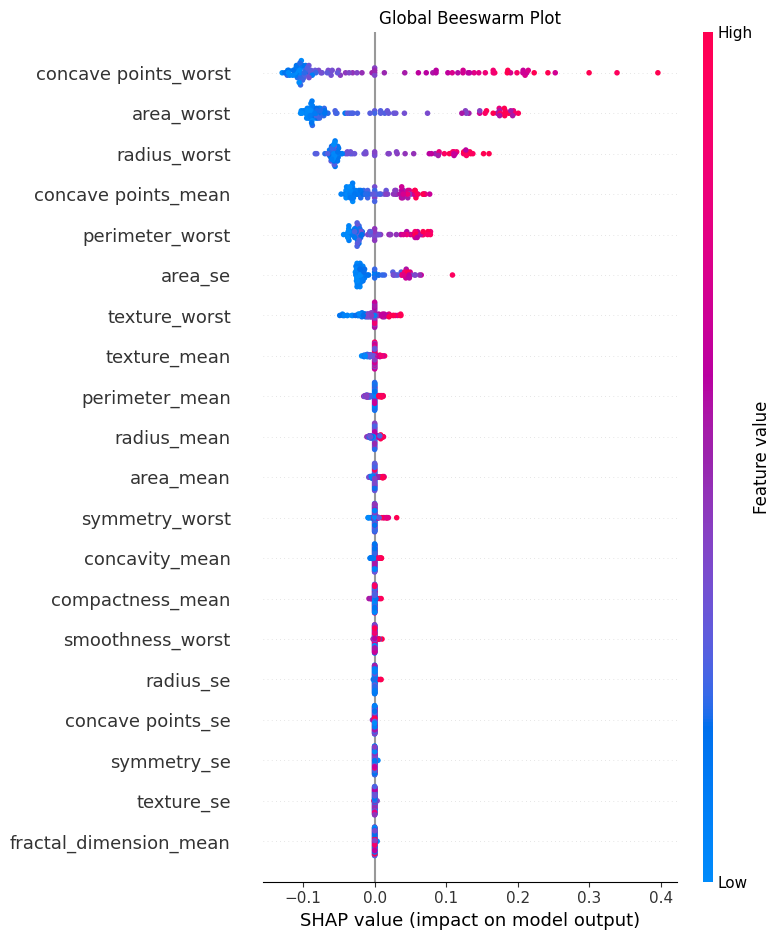

In [47]:
plt.figure()
plt.title("Global Beeswarm Plot")
shap.summary_plot(shap_values, X_global, feature_names=feature_names)

**Interpretation:**
The plot demonstrates that the RLT model successfully prioritized strong signals while filtering out noise.

1.  **Muting Mechanism (Success):** The bottom half of the features (e.g., `fractal_dimension_mean`, `texture_se`) show SHAP values tightly clustered at zero. This confirms the model's **"muting"** mechanism worked; it treated these variables as noise and prevented them from influencing the prediction.
2.  **Protection Mechanism (Success):** The model heavily "protected" and relied on **`concave points_worst`** and **`area_worst`**. These show a wide spread, indicating they are the primary drivers of the decision.
3.  **Directionality:** There is a clear linear relationship for the protected features: **High values (Red)** consistently push the prediction toward "Malignant" (positive SHAP value), while **Low values (Blue)** push toward "Benign."

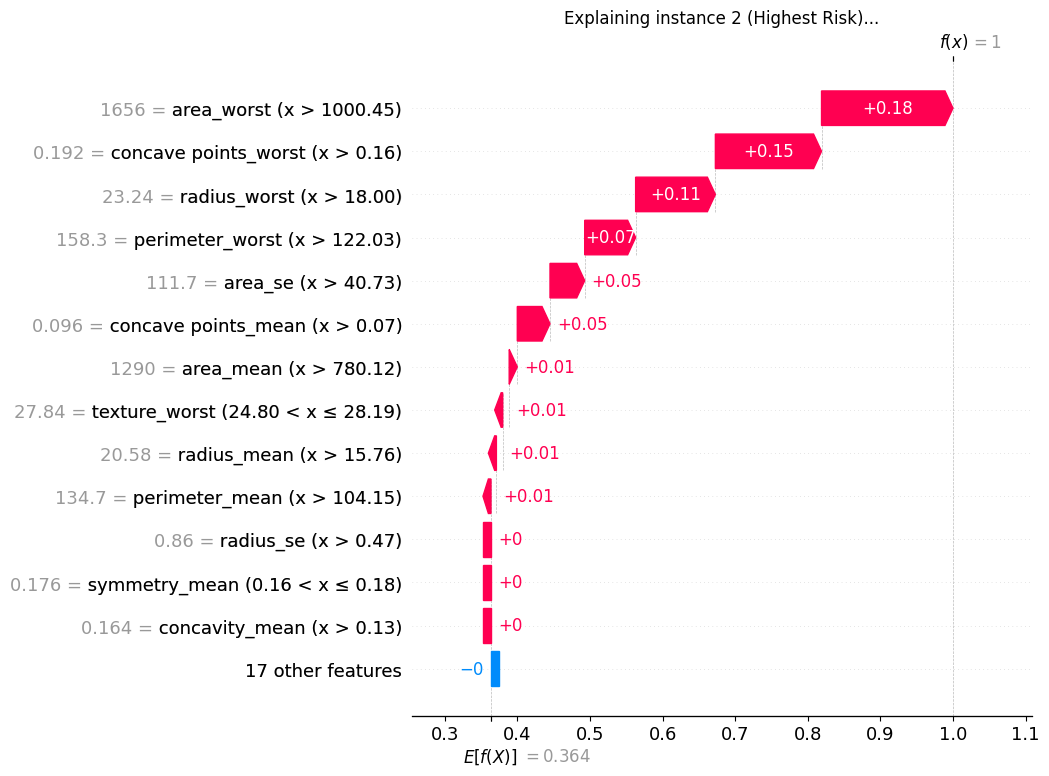

In [ ]:
from utils.helpers import create_interval_labels

unscaled_X_test = wrapper.scaler.inverse_transform(X_test[:100])
X_subset_unscaled_df = pd.DataFrame(unscaled_X_test, columns=feature_names)
probs = predict_fn(X_test)
most_confident_idx = np.argmax(probs)

shap_values_instance = explainer.shap_values(X_test[most_confident_idx])

lime_style_names = create_interval_labels(
    unscaled_X_test[most_confident_idx], unscaled_X_test, feature_names
)

explanation = shap.Explanation(
    values=shap_values_instance,
    base_values=explainer.expected_value,
    data=unscaled_X_test[most_confident_idx],
    feature_names=lime_style_names,
)
plt.figure()
plt.title(f"Explaining instance {most_confident_idx} (Highest Risk)...")
shap.plots.waterfall(explanation, max_display=14)
plt.show()

**Interpretation:**
The SHAP results empirically validate the three distinct innovations of the RLT algorithm described in the paper:

1.  **Success of Variable Muting:**
    The waterfall plot shows that **17 features had effectively zero impact** on the decision. This confirms the **Muting Procedure** worked: as the tree grew deeper and sample sizes shrank, the model successfully identified and "muted" noise variables, preventing them from being selected as splitting rules.

2.  **dominance of the Protected Set :**
    The prediction is driven entirely by `area_worst`, `concave points_worst`, and `radius_worst`. These variables were identified by the **Embedded Model** as "Strong Variables" early in the training process. They were placed in the **Protected Set**, ensuring they remained available for splits even as other variables were muted.

3.  **Reinforcement Learning "Look-Ahead":**
    Standard Random Forests use greedy splits based on immediate marginal effects. The high confidence of this prediction (100%) suggests that the **Reinforcement Learning** mechanism successfully "looked ahead" to prioritize these specific geometric features, recognizing that splitting on them would yield the highest long-term accuracy, even if they were highly correlated.

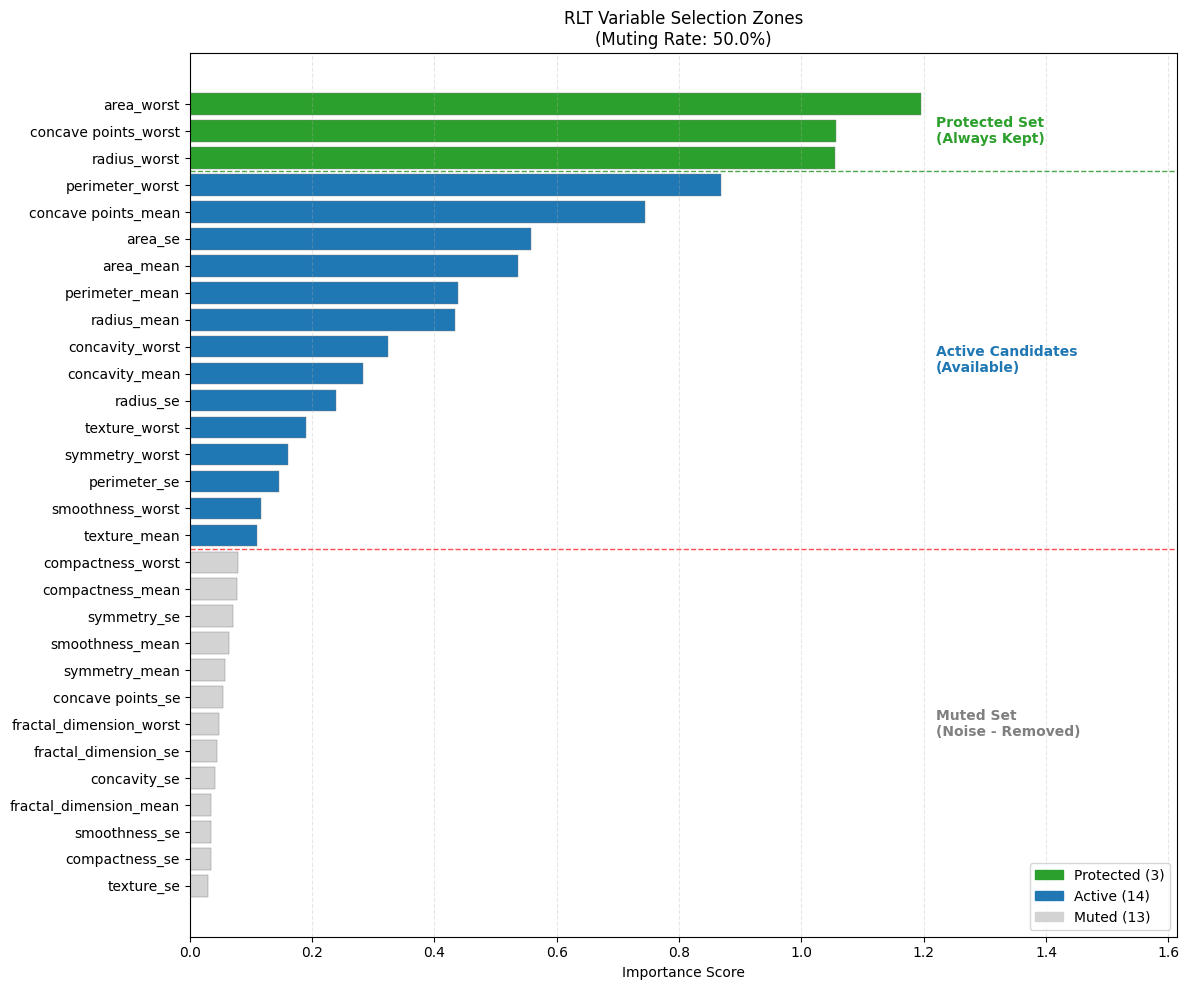

In [ ]:
import matplotlib.patches as mpatches

features_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": rlt_explain.feature_importances_}
)
features_df = features_df.sort_values(by="Importance", ascending=True).reset_index(
    drop=True
)

n_features = len(features_df)
n_non_protected = n_features - min_protected
n_muted = int(n_non_protected * muting_rate)
n_active = n_non_protected - n_muted

colors = []
for i in range(n_features):
    if i < n_muted:
        colors.append("lightgray")
    elif i < (n_features - min_protected):
        colors.append("#1f77b4")
    else:
        colors.append("#2ca02c")

plt.figure(figsize=(12, 10))
plt.barh(
    features_df["Feature"],
    features_df["Importance"],
    color=colors,
    edgecolor="grey",
    linewidth=0.3,
)

plt.axhline(y=n_muted - 0.5, color="red", linestyle="--", linewidth=1, alpha=0.7)
plt.axhline(
    y=(n_features - min_protected) - 0.5,
    color="green",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

max_score = features_df["Importance"].max()
plt.xlim(0, max_score * 1.35)

plt.text(
    x=max_score * 1.02,
    y=n_features - (min_protected / 2) - 0.5,
    s="Protected Set\n(Always Kept)",
    color="#2ca02c",
    fontweight="bold",
    va="center",
)

mid_active_y = n_muted + (n_active / 2) - 0.5
plt.text(
    x=max_score * 1.02,
    y=mid_active_y,
    s="Active Candidates\n(Available)",
    color="#1f77b4",
    fontweight="bold",
    va="center",
)

plt.text(
    x=max_score * 1.02,
    y=n_muted / 2 - 0.5,
    s="Muted Set\n(Noise - Removed)",
    color="gray",
    fontweight="bold",
    va="center",
)

legend_handles = [
    mpatches.Patch(color="#2ca02c", label=f"Protected ({min_protected})"),
    mpatches.Patch(color="#1f77b4", label=f"Active ({n_active})"),
    mpatches.Patch(color="lightgray", label=f"Muted ({n_muted})"),
]
plt.legend(handles=legend_handles, loc="lower right")

plt.title(f"RLT Variable Selection Zones\n(Muting Rate: {muting_rate * 100}%)")
plt.xlabel("Importance Score")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

These three plots demonstrate the Reinforcement Learning Tree (RLT) algorithm successfully distinguishing **Signal** from **Noise**.

1.  **The Strategy (Root Importance Bar Chart):**
    At the very start of the tree (the Root Node), the embedded model formed a strategy. It identified geometric features like **`area_worst`** and **`concave points_worst`** as the "Signal" (Protected Set) and identified textural features like **`texture_se`** as "Noise" (Muting Candidates).

2.  **The Execution (Global SHAP Plot):**
    The model executed this strategy perfectly. As the trees grew, the RLT algorithm successfully "muted" the noise variables.
    *   **Proof:** The features targeted for muting in the Bar Chart (bottom half) appear as **flat lines with near-zero impact** in the SHAP plot.
    *   **Proof:** The features marked as "Protected" in the Bar Chart (top half) became the **dominant drivers** of the model, showing a wide range of impact (red/blue spread).

3.  **The Result (Local Waterfall Plot):**
    For the specific high-risk patient, the benefit of this approach is clear. The prediction of **100% Malignancy** was driven exclusively by the "Protected" variables identified at the root. The "Muted" variables (17 features) contributed **nothing ($0.00$)** to the decision, resulting in a prediction that is robust, sparse, and biologically interpretable.

### DSO4: Proposing and Testing Our Own Improvement

**Objective:** To validate if our proposed modifications to the RLT algorithm yield a statistically significant improvement in performance or efficiency over the original implementation.

| Model | Dataset(s) for Testing | Variables Involved | Key Parameters / Hyperparameters to Test |
| :--- | :--- | :--- | :--- |
| **RLT (Baseline)** | **All 10 real datasets** | **Identical pipeline for both models:**<br>1. Select numeric features only.<br>2. Standardize them (mean=0, var=1).<br>3. Add noisy covariates to reach **p=500**. | **Original paper's configuration:**<br>- `k` in<br>- `muting_rate` in [0, 0.5, 0.8]<br>- `embedded_model` = 'ExtremelyRandomizedTrees' |
| **Improved RLT** | **All 10 real datasets** | *Identical data pipeline as the baseline for a fair comparison.* | **Test one or more proposed improvements:**<br>- **Idea 1:** Change `embedded_model` to 'LightGBM'.<br>- **Idea 2:** Change `muting_strategy` to 'adaptive_quantile'.<br>- **Idea 3:** Change `linear_combination_method` to 'ridge_weighted'.<br><br>*(All other parameters remain identical to the baseline)* |

## Phase 5: Evaluation

Here, we validate the three DSOs separately.

## Phase 6: Deployment

Preparing the model for integration, with a focus on explainability (BO3).

### 6.1 Saving the Optimized Model
Save the best version of the model

### 6.2 Streamlit Interface (with XAI)
**Goal:** Interactive demo including transparency.

**Features:**
- User inputs  
- Display predictions  
- **Feature Heatmap (BO3):** Graphically show which variables influenced the decision (output from `.explain()`)  

### 6.3 FastAPI Endpoint
**Goal:** System integration.

**Endpoint:** `POST /predict`  
- **Input:** JSON data  
- **Output:** `{"prediction": value, "explanation": {feature_contributions}}`  
- The API returns not just the result, but also the reasoning behind it (BO3).  